In [ ]:
import random
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
import shutil
import os

# The path to your restructured data
source_path = "/content/drive/MyDrive/OPIT/Capstone project/data/anomalib_data/Machine_S"

destination_path = "/content/Machine_S"

print(f"Copying data from Google Drive to local Colab storage...")
print(f"Source: {source_path}")

if os.path.exists(source_path):
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print("Done! The data is now fully loaded into Colab's fast memory.")
else:
    print("Error: Could not find the Machine_S folder in your Google Drive. Please double-check the path!")

Copying data from Google Drive to local Colab storage...
Source: /content/drive/MyDrive/OPIT/Capstone project/data/anomalib_data/Machine_S
Done! The data is now fully loaded into Colab's fast memory.


In [ ]:
# Suppress minor PyTorch deprecation warnings
warnings.filterwarnings("ignore")

# --- Configuration ---
# Source dataset (restructured anomalib_data layout required)
DATASET_ROOT = "/content/Machine_S"

# Tiny subset output location
SUBSET_ROOT = "/content/overfit_subset/train"

# Number of images to sample from each class (good / bad)
N_NORMAL = 10
N_DEFECTIVE = 10

# Training hyperparameters
N_EPOCHS = 100
LEARNING_RATE = 1e-3
IMAGE_SIZE = 224

# Random seed for reproducible sampling
SEED = 42

# Output directory for the learning curve plot
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
SAVE_PATH = RESULTS_DIR / "overfit_curves.png"

In [ ]:
def prepare_overfit_subset(
    dataset_root: str,
    output_root: str = SUBSET_ROOT,
    n_normal: int = N_NORMAL,
    n_defective: int = N_DEFECTIVE,
    seed: int = SEED,
):
    """
    Copy a small random subset of images into a flat train/ folder
    so PyTorch ImageFolder can read it.

    Layout created:
        output_root/
            good/   (n_normal images from train/good)
            bad/    (n_defective images from test/bad)
    """
    random.seed(seed)
    root = Path(dataset_root)
    out = Path(output_root)

    if out.exists():
        shutil.rmtree(out)

    folders_to_sample = [
        ("good", "train/good"),
        ("bad", "test/bad"),
    ]

    print(f"Sampling {n_normal} Good and {n_defective} Bad images...")

    for label, folder in folders_to_sample:
        target_dir = root / folder
        # Ignore hidden system files such as .DS_Store
        imgs = [f for f in target_dir.iterdir() if f.is_file() and not f.name.startswith(".")]

        n = n_normal if label == "good" else n_defective
        actual_n = min(n, len(imgs))
        chosen = random.sample(imgs, actual_n)

        dest = out / label
        dest.mkdir(parents=True, exist_ok=True)

        for img in chosen:
            shutil.copy2(img, dest / img.name)

    print(f"\nTiny subset written to {output_root}/")
    print(f"  Good images : {len(list((out / 'good').glob('*')))}")
    print(f"  Bad images  : {len(list((out / 'bad').glob('*')))}")

In [ ]:
def run_overfit_test(subset_root: str = SUBSET_ROOT):
    """
    Train ResNet-18 with no regularisation on the tiny subset.
    Stops early if 100% accuracy is achieved before N_EPOCHS.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # No augmentation — we want to overfit
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        # ResNet expects 3-channel input; convert grayscale X-rays accordingly
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])

    # ImageFolder assigns class indices based on subfolder names
    dataset = datasets.ImageFolder(root=subset_root, transform=transform)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    print(f"\nStarting Overfit Sanity Test on {device.upper()}")
    print(f"Classes found : {dataset.classes}")
    print(f"Total samples : {len(dataset)}\n")

    # Pretrained ResNet-18 with the final layer replaced for binary classification
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"loss": [], "accuracy": []}

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total * 100
        history["loss"].append(total_loss)
        history["accuracy"].append(acc)

        # Log every 10 epochs, or immediately on reaching 100%
        if epoch % 10 == 0 or acc == 100.0:
            print(f"Epoch {epoch:>3} | Loss: {total_loss:.4f} | Train Acc: {acc:.1f}%")
            if acc == 100.0:
                print(f"\nSUCCESS: Reached 100% accuracy at epoch {epoch}.")
                print("This confirms your X-ray defects are learnable by a CNN.")
                break

    # Learning curve plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history["loss"], color="tomato", lw=2)
    ax1.set_title("Training Loss (target: 0)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)

    ax2.plot(history["accuracy"], color="steelblue", lw=2)
    ax2.axhline(100, color="green", linestyle="--", alpha=0.5, label="100% target")
    ax2.set_title("Training Accuracy (target: 100%)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 105)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(
        "Overfitting Sanity Test — ResNet-18 on 20 X-Ray Images",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(SAVE_PATH, dpi=150)
    plt.close()
    print(f"\nLearning curves saved to {SAVE_PATH}")


if __name__ == "__main__":
    prepare_overfit_subset(dataset_root=DATASET_ROOT)
    run_overfit_test(subset_root=SUBSET_ROOT)

Sampling 10 Good and 10 Bad images...

Tiny subset written to /content/overfit_subset/train/
  Good images : 10
  Bad images  : 10

Starting Overfit Sanity Test on CUDA
Classes found : ['bad', 'good']
Total samples : 20

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Epoch   3 | Loss: 0.0442 | Train Acc: 100.0%

SUCCESS: Reached 100% accuracy at epoch 3.
This confirms your X-ray defects are learnable by a CNN.

Learning curves saved to results/overfit_curves.png


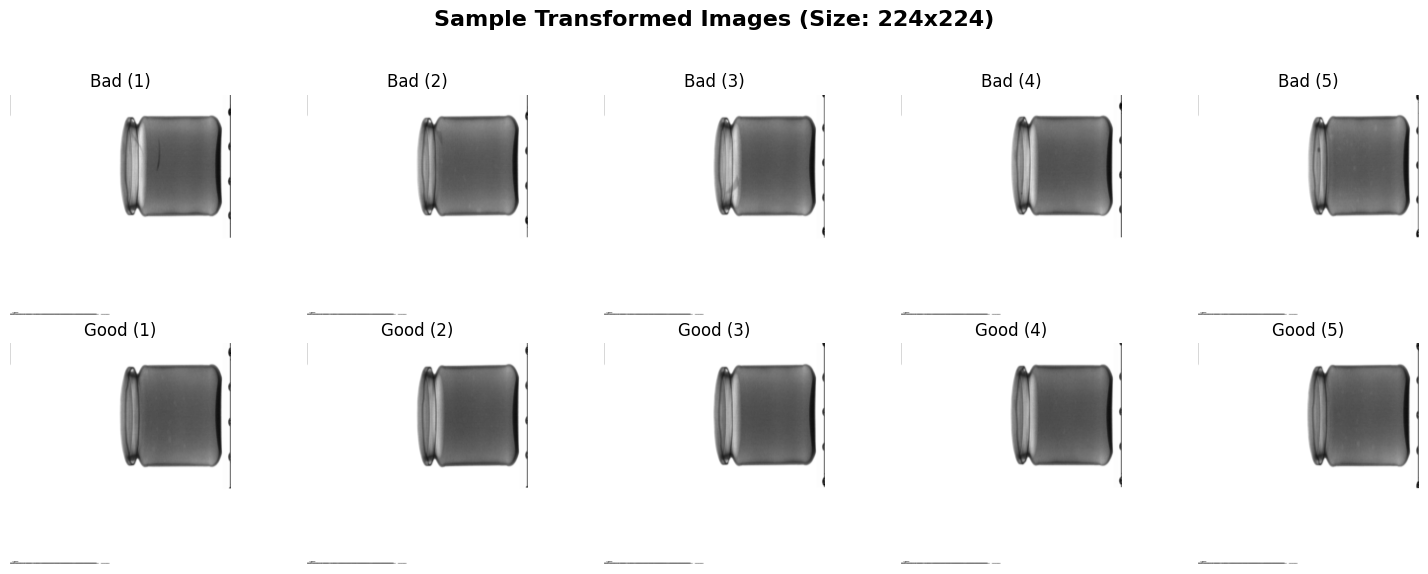

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from pathlib import Path
from PIL import Image
import numpy as np
import torch

def display_transformed_images(subset_root, image_size, num_images_to_show=5):
    subset_path = Path(subset_root)
    classes = [d.name for d in subset_path.iterdir() if d.is_dir()]

    # Define the same transformations as in run_overfit_test
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])

    plt.figure(figsize=(15, len(classes) * 3)) # Adjust figure size dynamically

    for i, cls in enumerate(sorted(classes)):
        class_path = subset_path / cls
        images = list(class_path.glob('*'))
        display_images = images[:num_images_to_show]

        for j, img_path in enumerate(display_images):
            ax = plt.subplot(len(classes), num_images_to_show, i * num_images_to_show + j + 1)
            try:
                img = Image.open(img_path)
                # Apply the transformation
                transformed_img = transform(img)

                # Convert tensor to numpy array for display
                # Undo normalization: (img * std) + mean
                mean = np.array([0.5, 0.5, 0.5]).reshape((3, 1, 1))
                std = np.array([0.5, 0.5, 0.5]).reshape((3, 1, 1))
                display_array = (transformed_img.numpy() * std) + mean

                # Clip values to [0, 1] as some might fall outside after undoing normalization
                display_array = np.clip(display_array, 0, 1)

                # Transpose from (C, H, W) to (H, W, C) for matplotlib
                ax.imshow(np.transpose(display_array, (1, 2, 0)))
            except Exception as e:
                print(f"Could not load or transform image {img_path}: {e}")
                ax.text(0.5, 0.5, 'Error', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            ax.set_title(f'{cls.capitalize()} ({j+1})')
            ax.axis('off')

    plt.suptitle(f'Sample Transformed Images (Size: {image_size}x{image_size})', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

display_transformed_images(SUBSET_ROOT, IMAGE_SIZE, num_images_to_show=5)